In [1]:
import numpy as np
import pandas as pd
from stl import mesh
import matplotlib.pyplot as plt

from src.core.core import *
from src.core.transforms.translation import *
from src.core.transforms.rotation import *
from src.core.transforms.flexibility import *

In [2]:
stl_name = "rightWing"
stl_path = "D:\Research\Kinematics_App\Projectfiles\\rightWing.stl"
stl = mesh.Mesh.from_file(stl_path)

vectors = stl.vectors
vectors = np.array(vectors).reshape(-1, 3)
min_x = np.min(vectors[:, 0])
max_x = np.max(vectors[:, 0])
min_y = np.min(vectors[:, 1])
max_y = np.max(vectors[:, 1])
min_z = np.min(vectors[:, 2])
max_z = np.max(vectors[:, 2])

major_axis = max_x - min_x
minor_axis = max_y - min_y

translation_transform = Translation_COM()
rotation_transform = Rotation_EulerAngles('ZYX')




positions = np.array(pd.read_csv("D:\Research\Kinematics_App\Projectfiles\\accelerometer_values.csv"))
gamma_values = np.array(pd.read_csv("D:\Research\Kinematics_App\Projectfiles\\alpha_values.csv"))
beta_values = np.array(pd.read_csv("D:\Research\Kinematics_App\Projectfiles\\beta_values.csv"))
alpha_values = np.array(pd.read_csv("D:\Research\Kinematics_App\Projectfiles\gamma_values.csv"))
m_values = np.array(pd.read_csv("D:\Research\Kinematics_App\Projectfiles\\flexibility_values.csv"))

flexibility_transform = Flexibility_type2(x = False, y = False, z = True, major_axis = major_axis, minor_axis = minor_axis ,array_values = m_values, time_period = len(m_values), p=1)

object_temp = Object3D(stl_name, stl, translation_transform=translation_transform, rotation_transform=rotation_transform, flexibility_transform=flexibility_transform)

angles = np.hstack((alpha_values, beta_values, gamma_values))

sprite = Sprite(object_temp, positions, angles)

scene = Scene([sprite])

for i in range(0, len(positions)):
    scene.save_stl(i, "D:\Research\Kinematics_App\Projectfiles\\output\\output" + str(i) + ".stl")

In [3]:
temp_stl1 = copy.deepcopy(stl)
vectors = temp_stl1.vectors
vectors = np.array(vectors).reshape(-1, 3) + np.array([10, 20, 0])
temp_stl1.vectors = vectors.reshape(-1, 3, 3)
temp_stl1.save("D:\Research\Kinematics_App\Projectfiles\\output\\output_theta.stl")



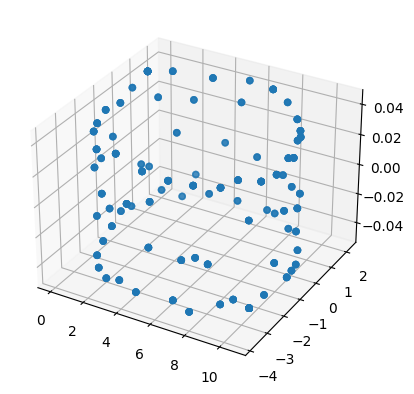

In [4]:
temp_stl = stl.vectors
temp_stl = np.array(temp_stl).reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(temp_stl[:, 0], temp_stl[:, 1], temp_stl[:, 2])
plt.show()

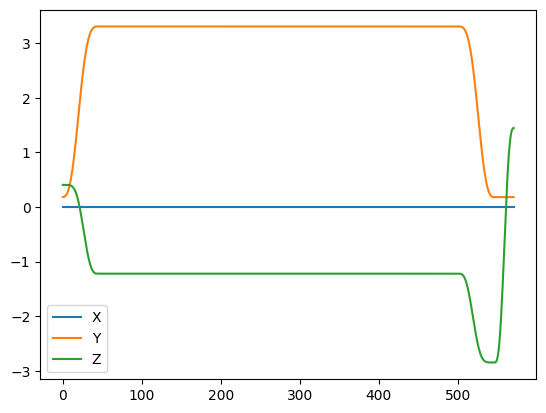

In [5]:
pos_x = positions[:, 0]
pos_y = positions[:, 1]
pos_z = positions[:, 2]

fig = plt.figure()
# Making plots
plt.plot(pos_x, label="X")
plt.plot(pos_y, label="Y")
plt.plot(pos_z, label="Z")
plt.legend()
plt.show()